# <center> Verif dataloader </center>

In [1]:
from pathlib import Path
import sys
from typing import Tuple
import ast
import json
from typing import Dict, List, Optional, Union
import math
import numpy as np
import pandas as pd
import rasterio
import torch
torch.multiprocessing.set_sharing_strategy('file_system')
from rasterio.windows import Window
from torch.utils.data import Dataset, DataLoader, Subset
from tqdm.auto import tqdm
from dataloader_CIRCA.tools.data_processor import SentinelDataProcessor
from dataloader_CIRCA.datasets import CircaPatchDataSet
import h5py
from dataloader_CIRCA.tools.positional_encoding import get_position_for_positional_encoding
import random
from omegaconf import DictConfig, OmegaConf
from torch import Tensor
from dataloader_CIRCA.tools.mask_generation import overlay_seq_with_clouds, masks_init_filling
from dataloader_CIRCA.tools.sampling import sample_indices_masked_frames
from dataloader_CIRCA.tools.positional_encoding import str2date
from dataloader_CIRCA.datasets.UTILISE_ligth import CIRCA_HDF5_Dataset

import matplotlib.pyplot as plt

import os
from pathlib import Path
import numpy as np
import pandas as pd

from matplotlib.widgets import Button
import ipywidgets as widgets
import matplotlib
import matplotlib.pyplot as plt
import mpl_interactions
from mpl_interactions import ipyplot as iplt
from mpl_interactions import hyperslicer
import ipywidgets as widgets

from dataloader_CIRCA.viz.ts_vis import TimeSerieVisualizer

%matplotlib ipympl

In [2]:
path_dataset_circa = Path("/home/SPeillet/Downloads/data")
data_optique = path_dataset_circa / "optique_dataset"
data_radar = path_dataset_circa / "radar_dataset_v4"
image_size = [256, 256]
overlap = 0
SAMPLING_SUBSET = 1.0
output_file =  path_dataset_circa / "toy_circa_ligth_0.5.hdf5"

filter_settings = {
    "type": "cloud-free",           # Strategy for removing observations with data gaps. ['cloud-free', 'cloud-free_consecutive']
    "min_length": 10,                # Minimum sequence length.
    "return_valid_obs_only": True,  # True to return the cloud-filtered sequences, False otherwise.
    # "max_t_sampling": 10,            # Maximum temporal sampling frequency in days.
}

mask_kwargs = {
    "mask_type": "random_clouds",              # Mask the input time series with randomly sampled cloud masks or the actual cloud masks. ['random_clouds', 'real_clouds']
    "ratio_masked_frames": 0.5,                # Ratio of partially/fully masked images per image time series (upper bound).
    "ratio_fully_masked_frames": 0.0,          # Ratio of fully masked images per image time series (upper bound).
    "fixed_masking_ratio": False,              # True to vary the masking ratio across different image time series, False otherwise.
    "non_masked_frames": [0],                  # list of int, time steps to be excluded from masking. E.g., [0] never masks the first frame in a sequence.
    "intersect_real_cloud_masks": False,       # True to intersect randomly sampled cloud masks with the actual cloud masks, False otherwise.
    "dilate_cloud_masks": False,               # True to dilate the cloud masks before masking, False otherwise.
    "fill_type": "fill_value",                 # Strategy for initializing masked pixels. ['fill_value', 'white_noise', 'mean']
    "fill_value": 1,                           # Pixel value of masked pixels. Used if fill_type == 'fill_value'.
    "p_filter": 0.1,
}

In [3]:
# Import des données depuis un fichier hdf5
dataset = CIRCA_HDF5_Dataset(
    hdf5_file_read=output_file,
    filter_settings=filter_settings,
    mask_kwargs=mask_kwargs,
    max_seq_length=25,
    process_data=False,
)
sample = next(iter(dataset))
print(sample.keys())

dict_keys(['x', 'y', 'masks', 'masks_valid_obs', 'position_days', 'days', 'sample_index', 'c_index_rgb', 'c_index_nir', 'S2_dates', 'cloud_prob', 'cloud_mask', 'S1_dates'])


In [ ]:
t = 14
inputs = sample["x"]
targets = sample["y"]
arr_inputs = inputs[t, [3, 2, 1], :, :].numpy().transpose(1, 2, 0) / 5000
arr_targets = targets[t, [3, 2, 1], :, :].numpy().transpose(1, 2, 0) / 5000
print(f"{arr_inputs.shape}")
print(f"{arr_targets.shape}")
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(arr_inputs)
plt.title("Input")
plt.subplot(1, 2, 2)
plt.imshow(arr_targets)
plt.title("Target")
plt.show()


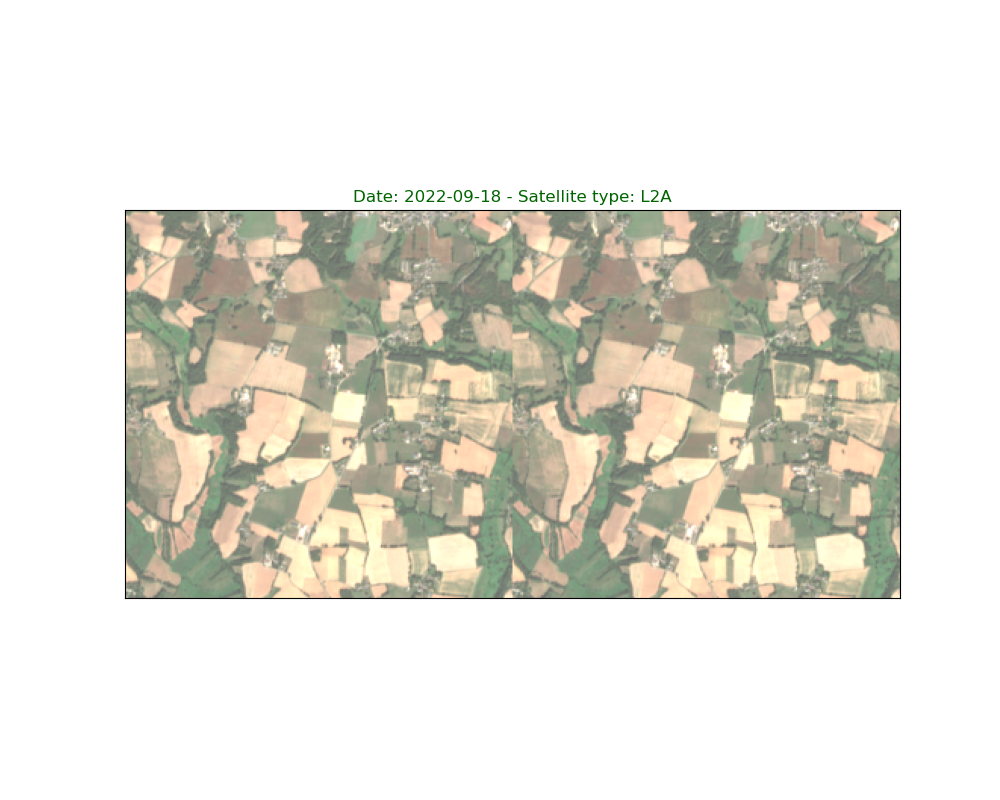

In [5]:
from dataloader_CIRCA.viz.ts_vis import TimeSerieVisualizer
ui = TimeSerieVisualizer(
    data={
        "img": sample["x"][:, :10, :, :].numpy().transpose(0, 2, 3, 1),
        "pred": sample["y"].numpy().transpose(0, 2, 3, 1),
    },
    dates=sample["S2_dates"],
    sat_types="L2A",
)()